# Sampling Experiments for Imbalanced Employee Churn Data

This notebook tests various sampling techniques to handle class imbalance:
- SMOTE variants (Standard, Borderline, ADASYN)
- Undersampling methods (Random, Tomek Links, NearMiss, ENN)
- Combined approaches (SMOTE + Tomek, SMOTE + ENN)
- Class weight strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
import category_encoders as ce
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Sampling libraries
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss, EditedNearestNeighbours
from imblearn.combine import SMOTETomek, SMOTEENN

# Set random seed
np.random.seed(42)

## 1. Load Engineered Data

In [14]:
# Load engineered data (or original if not available)
try:
    df = pd.read_csv('../data/employee-engineered.csv')
    print("Loaded engineered dataset")
except FileNotFoundError:
    df = pd.read_csv('../data/employee-attrition.csv')
    df.columns = df.columns.str.lower()
    df['attrition'] = (df['attrition'] == 'Yes').astype(int)
    print("Loaded original dataset")

print(f"\nDataset shape: {df.shape}")
print(f"Attrition distribution:\n{df['attrition'].value_counts()}")
print(f"Attrition rate: {df['attrition'].mean():.2%}")

Loaded engineered dataset

Dataset shape: (1470, 35)
Attrition distribution:
attrition
0    1233
1     237
Name: count, dtype: int64
Attrition rate: 16.12%


## 2. Prepare Data

In [15]:
# Remove constant columns
constant_cols = ['employeecount', 'standardhours', 'over18']
df = df.drop(columns=[col for col in constant_cols if col in df.columns])

# Separate features and target
X = df.drop('attrition', axis=1)
y = df['attrition']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols[:5]}...")
print(f"Numerical columns ({len(num_cols)}): {num_cols[:5]}...")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}, Attrition rate: {y_train.mean():.2%}")
print(f"Test set: {X_test.shape}, Attrition rate: {y_test.mean():.2%}")

Categorical columns (6): ['businesstravel', 'department', 'educationfield', 'jobrole', 'maritalstatus']...
Numerical columns (25): ['dailyrate', 'distancefromhome', 'education', 'employeenumber', 'environmentsatisfaction']...

Train set: (984, 31), Attrition rate: 16.16%
Test set: (486, 31), Attrition rate: 16.05%


## 3. Preprocessing Pipeline

In [16]:
# Encode categorical variables
ohe = ce.OneHotEncoder(cols=cat_cols, use_cat_names=True)
X_train_encoded = ohe.fit_transform(X_train)
X_test_encoded = ohe.transform(X_test)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Encoded and scaled train set: {X_train_scaled.shape}")
print(f"Encoded and scaled test set: {X_test_scaled.shape}")

Encoded and scaled train set: (984, 51)
Encoded and scaled test set: (486, 51)


## 4. Baseline Model (No Sampling)

In [17]:
# Train baseline model
lr_baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

# Predictions
y_pred_baseline = lr_baseline.predict(X_test_scaled)
y_proba_baseline = lr_baseline.predict_proba(X_test_scaled)[:, 1]

# Metrics
ap_baseline = average_precision_score(y_test, y_proba_baseline)

print("Baseline Model (Class Weights Only):")
print(f"Average Precision: {ap_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['No Attrition', 'Attrition']))

Baseline Model (Class Weights Only):
Average Precision: 0.5726

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.94      0.79      0.86       408
   Attrition       0.39      0.72      0.51        78

    accuracy                           0.78       486
   macro avg       0.67      0.75      0.68       486
weighted avg       0.85      0.78      0.80       486



## 5. Sampling Experiments

In [37]:
# Dictionary to store results
sampling_results = {}

def evaluate_sampling(X_resampled, y_resampled, X_test, y_test, method_name):
    """
    Train model on resampled data and evaluate.
    """
    # Train model
    model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    model.fit(X_resampled, y_resampled)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    ap_score = average_precision_score(y_test, y_proba)
    
    # Store results
    sampling_results[method_name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'ap_score': ap_score,
        'class_distribution': Counter(y_resampled)
    }
    
    print(f"\n{method_name}:")
    print(f"  Resampled distribution: {Counter(y_resampled)}")
    print(f"  Average Precision: {ap_score:.4f}")
    print(f"  Improvement over baseline: {ap_score - ap_baseline:+.4f}")
    
    return ap_score

### 5.1 SMOTE Variants

In [38]:
print("="*60)
print("SMOTE VARIANTS")
print("="*60)

# Standard SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
evaluate_sampling(X_smote, y_smote, X_test_scaled, y_test, 'SMOTE')

# Borderline SMOTE
borderline_smote = BorderlineSMOTE(random_state=42)
X_borderline, y_borderline = borderline_smote.fit_resample(X_train_scaled, y_train)
evaluate_sampling(X_borderline, y_borderline, X_test_scaled, y_test, 'Borderline-SMOTE')

# ADASYN
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
evaluate_sampling(X_adasyn, y_adasyn, X_test_scaled, y_test, 'ADASYN')

SMOTE VARIANTS

SMOTE:
  Resampled distribution: Counter({0: 825, 1: 825})
  Average Precision: 0.5820
  Improvement over baseline: +0.0094

Borderline-SMOTE:
  Resampled distribution: Counter({0: 825, 1: 825})
  Average Precision: 0.5578
  Improvement over baseline: -0.0148

ADASYN:
  Resampled distribution: Counter({0: 825, 1: 813})
  Average Precision: 0.5599
  Improvement over baseline: -0.0127


0.5598892722736715

### 5.2 Undersampling Methods

In [39]:
print("\n" + "="*60)
print("UNDERSAMPLING METHODS")
print("="*60)

# Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
evaluate_sampling(X_rus, y_rus, X_test_scaled, y_test, 'Random Undersampling')

# Tomek Links
tomek = TomekLinks()
X_tomek, y_tomek = tomek.fit_resample(X_train_scaled, y_train)
evaluate_sampling(X_tomek, y_tomek, X_test_scaled, y_test, 'Tomek Links')

# NearMiss
nearmiss = NearMiss(version=1)
X_nearmiss, y_nearmiss = nearmiss.fit_resample(X_train_scaled, y_train)
evaluate_sampling(X_nearmiss, y_nearmiss, X_test_scaled, y_test, 'NearMiss')

# Edited Nearest Neighbours
enn = EditedNearestNeighbours()
X_enn, y_enn = enn.fit_resample(X_train_scaled, y_train)
evaluate_sampling(X_enn, y_enn, X_test_scaled, y_test, 'Edited Nearest Neighbours')


UNDERSAMPLING METHODS

Random Undersampling:
  Resampled distribution: Counter({0: 159, 1: 159})
  Average Precision: 0.5059
  Improvement over baseline: -0.0667

Tomek Links:
  Resampled distribution: Counter({0: 792, 1: 159})
  Average Precision: 0.5672
  Improvement over baseline: -0.0054

NearMiss:
  Resampled distribution: Counter({0: 159, 1: 159})
  Average Precision: 0.2626
  Improvement over baseline: -0.3100

Edited Nearest Neighbours:
  Resampled distribution: Counter({0: 625, 1: 159})
  Average Precision: 0.5545
  Improvement over baseline: -0.0181


0.554520634778833

### 5.3 Combined Approaches

In [40]:
print("\n" + "="*60)
print("COMBINED APPROACHES")
print("="*60)

# SMOTE + Tomek Links
smote_tomek = SMOTETomek(random_state=42)
X_smote_tomek, y_smote_tomek = smote_tomek.fit_resample(X_train_scaled, y_train)
evaluate_sampling(X_smote_tomek, y_smote_tomek, X_test_scaled, y_test, 'SMOTE + Tomek')

# SMOTE + ENN
smote_enn = SMOTEENN(random_state=42)
X_smote_enn, y_smote_enn = smote_enn.fit_resample(X_train_scaled, y_train)
evaluate_sampling(X_smote_enn, y_smote_enn, X_test_scaled, y_test, 'SMOTE + ENN')


COMBINED APPROACHES

SMOTE + Tomek:
  Resampled distribution: Counter({0: 824, 1: 824})
  Average Precision: 0.5809
  Improvement over baseline: +0.0083

SMOTE + ENN:
  Resampled distribution: Counter({1: 805, 0: 438})
  Average Precision: 0.5017
  Improvement over baseline: -0.0709


0.501681321827496

## 6. Results Comparison


SAMPLING METHODS COMPARISON
                   Method  Average Precision  Improvement
                    SMOTE           0.581985     0.009387
            SMOTE + Tomek           0.580861     0.008263
 Baseline (Class Weights)           0.572598     0.000000
              Tomek Links           0.567245    -0.005353
                   ADASYN           0.559889    -0.012709
         Borderline-SMOTE           0.557830    -0.014768
Edited Nearest Neighbours           0.554521    -0.018077
     Random Undersampling           0.505867    -0.066731
              SMOTE + ENN           0.501681    -0.070917
                 NearMiss           0.262584    -0.310014


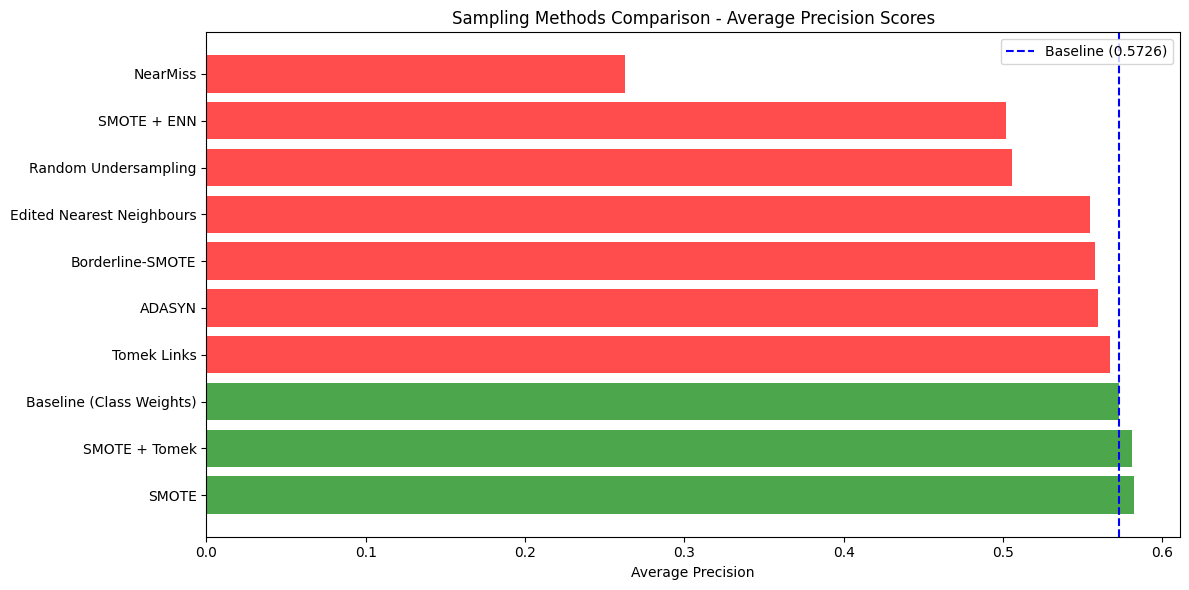

In [41]:
# Create results dataframe
results_df = pd.DataFrame([
    {'Method': 'Baseline (Class Weights)', 'Average Precision': ap_baseline}
] + [
    {'Method': method, 'Average Precision': results['ap_score']}
    for method, results in sampling_results.items()
])

results_df = results_df.sort_values('Average Precision', ascending=False)
results_df['Improvement'] = results_df['Average Precision'] - ap_baseline

print("\n" + "="*80)
print("SAMPLING METHODS COMPARISON")
print("="*80)
print(results_df.to_string(index=False))

# Visualize results
plt.figure(figsize=(12, 6))
colors = ['red' if x < ap_baseline else 'green' for x in results_df['Average Precision']]
plt.barh(results_df['Method'], results_df['Average Precision'], color=colors, alpha=0.7)
plt.axvline(ap_baseline, color='blue', linestyle='--', label=f'Baseline ({ap_baseline:.4f})')
plt.xlabel('Average Precision')
plt.title('Sampling Methods Comparison - Average Precision Scores')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Precision-Recall Curves

['SMOTE', 'SMOTE + Tomek', 'Tomek Links', 'ADASYN', 'Borderline-SMOTE']


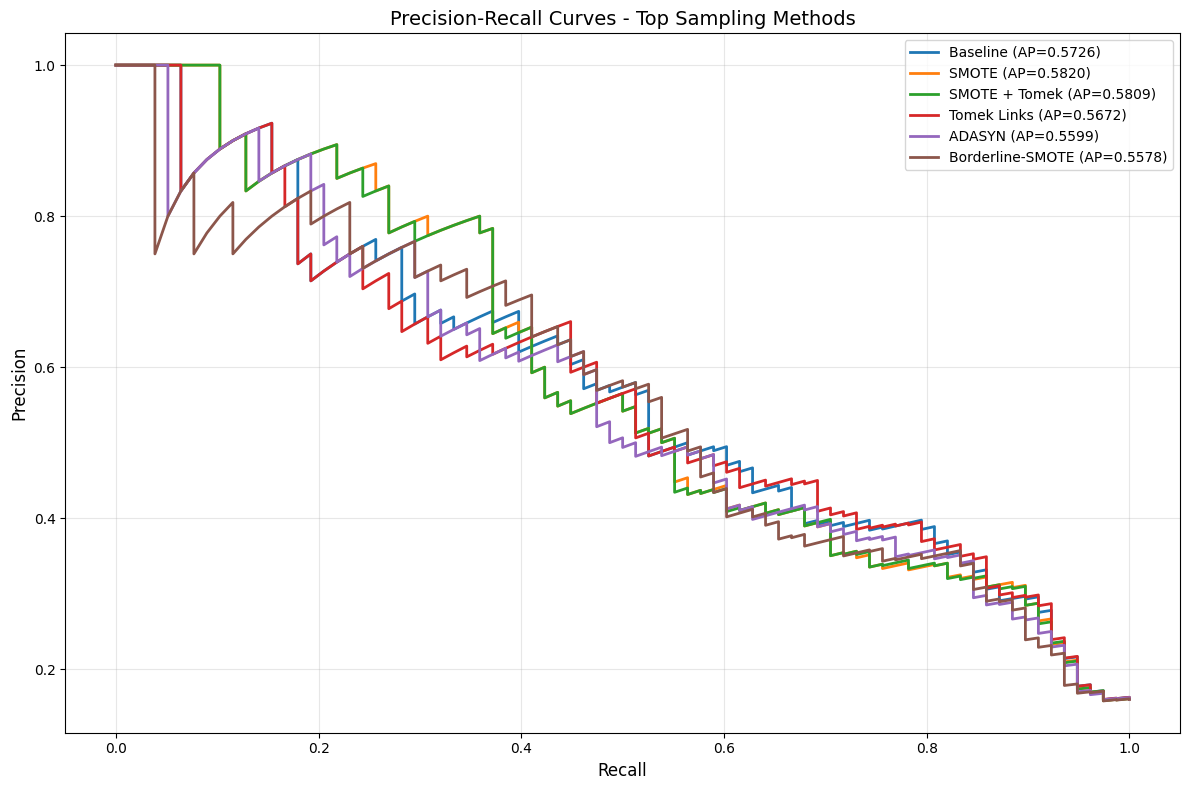

In [42]:
# Plot PR curves for top 5 methods

top_methods = [m for m in results_df.head(6)['Method'].tolist() if m != "Baseline (Class Weights)"]
print(top_methods)
plt.figure(figsize=(12, 8))

# Baseline
precision, recall, _ = precision_recall_curve(y_test, y_proba_baseline)
plt.plot(recall, precision, label=f'Baseline (AP={ap_baseline:.4f})', linewidth=2)

# Top sampling methods
for method in top_methods:  # Skip baseline
    if method in sampling_results:
        y_proba = sampling_results[method]['y_proba']
        ap = sampling_results[method]['ap_score']
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        plt.plot(recall, precision, label=f'{method} (AP={ap:.4f})', linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - Top Sampling Methods', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Best Method Analysis


Best Sampling Method: SMOTE
Average Precision: 0.5820
Improvement over baseline: +0.0094 (+1.64%)

Class Distribution after SMOTE:
Counter({0: 825, 1: 825})

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.93      0.81      0.87       408
   Attrition       0.41      0.68      0.51        78

    accuracy                           0.79       486
   macro avg       0.67      0.75      0.69       486
weighted avg       0.85      0.79      0.81       486



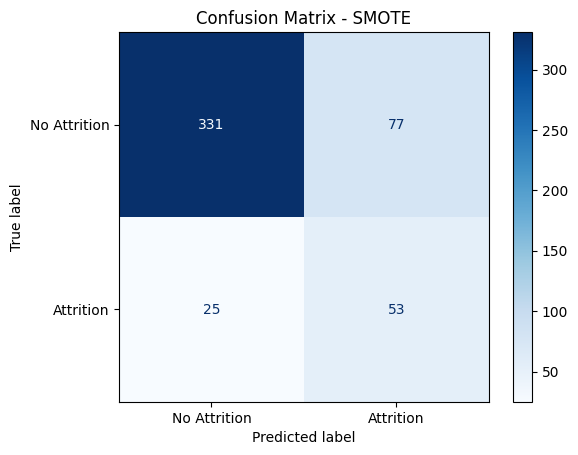

In [43]:
# Get best method
best_method = results_df.iloc[0]['Method']
best_ap = results_df.iloc[0]['Average Precision']

print(f"\nBest Sampling Method: {best_method}")
print(f"Average Precision: {best_ap:.4f}")
print(f"Improvement over baseline: {best_ap - ap_baseline:+.4f} ({(best_ap/ap_baseline - 1)*100:+.2f}%)")

if best_method != 'Baseline (Class Weights)':
    best_results = sampling_results[best_method]
    print(f"\nClass Distribution after {best_method}:")
    print(best_results['class_distribution'])
    
    print("\nClassification Report:")
    print(classification_report(y_test, best_results['y_pred'], 
                                target_names=['No Attrition', 'Attrition']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, best_results['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {best_method}')
    plt.show()

## 9. Save Results

In [36]:
# Save results
results_df.to_csv('../data/sampling_results.csv', index=False)
print("\nResults saved to: ../data/sampling_results.csv")

# Save best resampled data for future use
if best_method != 'Baseline (Class Weights)':
    # Get the resampled data for the best method
    best_method_key = best_method.replace(' ', '_').lower()
    print(f"\nBest sampling method: {best_method}")
    print(f"Use this method for final model training.")


Results saved to: ../data/sampling_results.csv

Best sampling method: Tomek Links
Use this method for final model training.
